In [7]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
import sys
import uproot
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
sys.path.append("../../")
import data_loading as dl
from importlib import reload
reload(dl)

from microfit import run_plotter as rp
from microfit import histogram as hist

from microfit import variable_definitions as vdef
from microfit import selections

# Load in the Runs 1-3 data

In [9]:
RUN = ["3"]
#RUN = ["1","2","3_nocrt","3_crt","4b","4c","4d","5"]
#RUN = ["1","2","3","4b","4c","4d","5"] #important that it's a string 1) new format to include latest runs 2) to include 'mc_pdg' otherwise it gets dropped

rundata, mc_weights, data_pot = dl.load_runs(
    RUN,
    data="bnb",
    loadpi0variables=False,
    loadshowervariables=True,
    loadrecoveryvars=False,
    loadsystematics=True,
    numupresel=False,
    loadnumuvariables=False,
    use_bdt=False,
    load_lee=False,
    load_nue_tki=True,
    blinded=True,
    load_crt_vars=False,
    enable_cache=True,
)

Loading run 3


In [6]:
print("category_1e1p" in rundata["mc"].columns)
print(rundata.keys())

True
dict_keys(['data', 'ext', 'mc', 'nue', 'drt'])


In [4]:
run_combo = ""
for run in RUN:
    run_combo += run
print(run_combo)
print(type(run_combo))

3
<class 'str'>


### Concatenate the dataframes and select just the signal in truth

In [5]:
from microfit import selections as sel

#print(sel.selection_categories)

selection = "OneP_xsec"
preselection = "OneP_new"
query = f"{sel.preselection_categories[preselection]['query']} and {sel.selection_categories[selection]['query']}"
#print(query)

all_mc = pd.concat([df for k, df in rundata.items() if k!='data'])
is_sig = all_mc['category_1e1p'] == 12
all_sig = all_mc.loc[is_sig]
sel_sig = all_sig.query(query, engine='python')

print(len(all_sig))

#plt.plot(sel_sig['TrueElecModMom'], sel_sig['mod_shr_p'], '+')


17855


### Making the resolution plot - 100 bins

In [6]:
run_combo = ""
for run in RUN:
    run_combo += run

variables = {
# #    '': {'reco': , 'truth': , 'nbins': , 'bounds': },
#     'Proton Kinetic Energy [GeV]': {'reco': 'trk_energy', 'truth': 'TrueLeadProtonKE', 'nbins': 10, 'bounds': (0, 1), 'range': [[0,1.3],[0,1.3]]},
#     'Proton Momentum [GeV/c]': {'reco': 'mod_trk_p', 'truth': 'TrueLeadProtonModMom', 'nbins': 20, 'bounds': (0, 1.5), 'range': [[0.1,2],[0.1,2]]},
#     'Proton X Momentum [GeV/c]': {'reco': 'trk_px', 'truth': 'TrueLeadProtonMomX', 'nbins': 20, 'bounds': (-1, 1), 'range': [[-1,1.25],[-1,1.25]]},
#     'Proton Y Momentum [GeV/c]': {'reco': 'trk_py', 'truth': 'TrueLeadProtonMomY', 'nbins': 20, 'bounds': (-1.5, 1.5), 'range': [[-1,1.5],[-1,1.5]]},
#     'Proton Z Momentum [GeV/c]': {'reco': 'trk_pz', 'truth': 'TrueLeadProtonMomZ', 'nbins': 20, 'bounds': (-1, 1.5),'range': [[-1,2],[-1,2]]},
#     'Electron Kinetic Energy [GeV]': {'reco': 'shr_energy_cali', 'truth': 'TrueElecKE', 'nbins': 16, 'bounds': (0, 4), 'range': [[0,4.6],[0,4.6]]},
#     'Electron Momentum [GeV/c]': {'reco': 'mod_shr_p', 'truth': 'TrueElecModMom', 'nbins': 20, 'bounds': (0, 5), 'range': [[0,4.6],[0,4.6]]},
#     'Electron X Momentum [GeV/c]': {'reco': 'shr_px', 'truth': 'TrueElecMomX', 'nbins': 12, 'bounds': (-1.5, 1.5), 'range': [[-1,1],[-1,1]]},
#     'Electron Y Momentum [GeV/c]': {'reco': 'shr_py', 'truth': 'TrueElecMomY', 'nbins': 12, 'bounds': (-1.5, 1.5), 'range': [[-1,1],[-1,1]]},
#     'Electron Z Momentum [GeV/c]': {'reco': 'shr_pz', 'truth': 'TrueElecMomZ', 'nbins': 12, 'bounds': (-1, 5), 'range': [[0,4.6],[0,4.6]]},
    '$\\delta p_T$ [GeV/c]': {'reco': 'RecoDeltaPT', 'truth': 'TrueDeltaPT', 'nbins': 10, 'bounds': (0, 2), 'range': [[0,1.75],[0,1.75]], 'bin_edges': [[0,0.3,1.75],[0,0.3,1.75]]},
    '$\\delta \\alpha_T$ [degrees]': {'reco': 'RecoDeltaAlphaT', 'truth': 'TrueDeltaAlphaT', 'nbins': 10, 'bounds': (0, 180), 'range': [[0,180],[0,180]], 'bin_edges': [[0,80,180],[0,80,180]]},
    '$p_n$ [GeV/c]': {'reco': 'RecoPN', 'truth': 'TruePN', 'nbins': 10, 'bounds': (0, 2), 'range': [[0,2.5],[0,2.5]], 'bin_edges': [[0,0.3,2.5],[0,0.3,2.5]]},
    '$\\alpha_{3D}$ [degrees]': {'reco': 'RecoAlpha3D', 'truth': 'TrueAlpha3D', 'nbins': 10, 'bounds': (0, 180), 'range': [[0,180],[0,180]], 'bin_edges': [[0,80,180],[0,80,180]]},
}

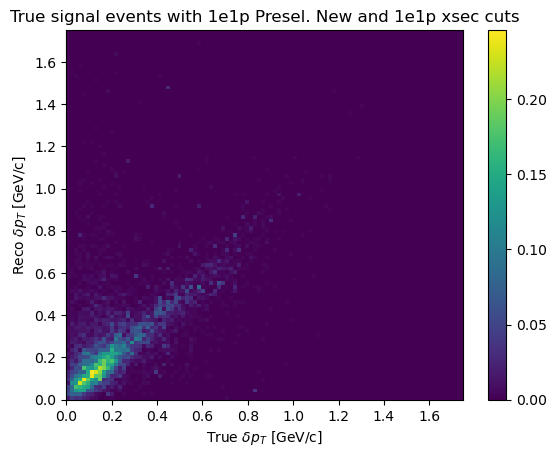

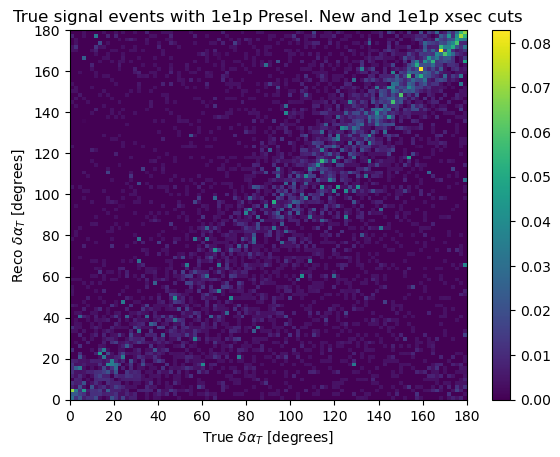

<Figure size 640x480 with 0 Axes>

In [11]:
from matplotlib.colors import LogNorm

for k, var in variables.items():
    #print(type(k))
    truth = variables[k]['truth']
    reco = variables[k]['reco']
    bounds = variables[k]['range']
    
    H, xedges, yedges = np.histogram2d(sel_sig[truth], sel_sig[reco], bins=100, weights=sel_sig["weights"], range=bounds)
    X, Y = np.meshgrid(xedges,yedges)
    plt.pcolormesh(X, Y, H.T, shading='flat') #, norm=LogNorm())
    plt.colorbar()
    plt.xlabel(f'True {k}')
    plt.ylabel(f'Reco {k}')
    
    plt.title(f"True signal events with {sel.preselection_categories[preselection]['title']} and {sel.selection_categories[selection]['title']}")
    #plt.savefig(f'plots/resolution_plots/resolution_2Dplots_{run_combo}_{preselection}_{selection}_{truth}_100bins.pdf', bbox_inches='tight')
    #plt.savefig(f'plots/resolution_plots/resolution_2Dplots_{run_combo}_{preselection}_{selection}_{truth}_100bins.png', bbox_inches='tight')
    plt.show()
    plt.clf()

### Resolution plot with 2 bins

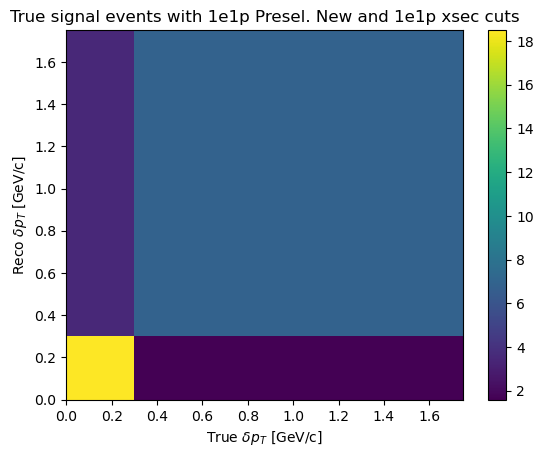

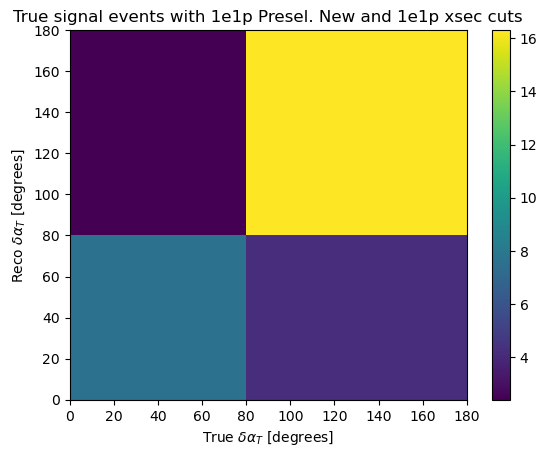

<Figure size 640x480 with 0 Axes>

In [12]:
for k, var in variables.items():
    #print(type(k))
    truth = variables[k]['truth']
    reco = variables[k]['reco']
    bounds = variables[k]['range']
    bin_edges = variables[k]['bin_edges']
    
    H, xedges, yedges = np.histogram2d(sel_sig[truth], sel_sig[reco], bins=bin_edges, weights=sel_sig["weights"], range=bounds)
    X, Y = np.meshgrid(xedges,yedges)
    plt.pcolormesh(X, Y, H.T, shading='flat') #, norm=LogNorm())
    plt.colorbar()
    plt.xlabel(f'True {k}')
    plt.ylabel(f'Reco {k}')
    
    plt.title(f"True signal events with {sel.preselection_categories[preselection]['title']} and {sel.selection_categories[selection]['title']}")
    #plt.savefig(f'plots/resolution_plots/resolution_2Dplots_{run_combo}_{preselection}_{selection}_{truth}_2bins.pdf', bbox_inches='tight')
    #plt.savefig(f'plots/resolution_plots/resolution_2Dplots_{run_combo}_{preselection}_{selection}_{truth}_2bins.png', bbox_inches='tight')
    plt.show()
    plt.clf()